In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler


In [2]:
df = pd.read_csv("../data/heart_disease_cleaned.csv")

X = df.drop(columns=["target"])
y = df["target"]


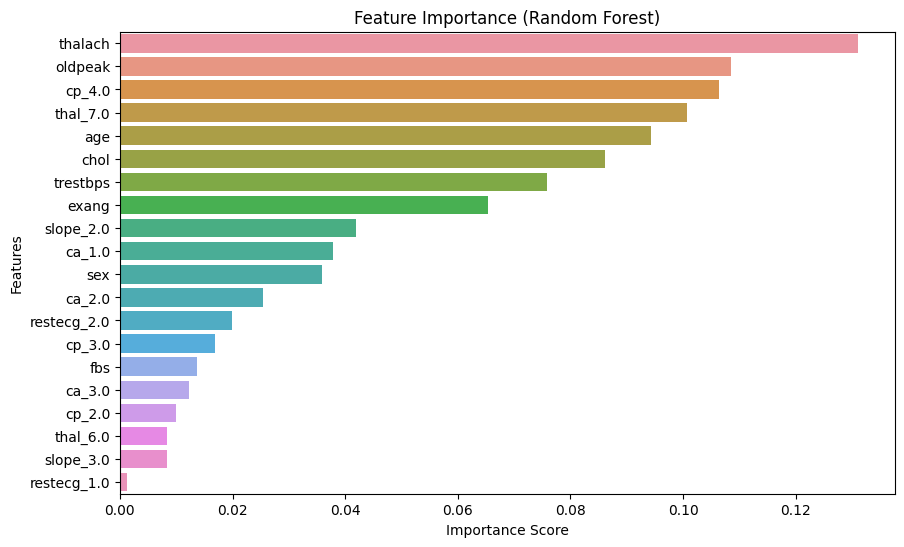

Top features by Random Forest: ['thalach', 'oldpeak', 'cp_4.0', 'thal_7.0', 'age', 'chol', 'trestbps', 'exang']


In [15]:
# 1. Feature Importance (Random Forest)
# -----------------------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

top_rf = list(importances.head(8).index)
print("Top features by Random Forest:", top_rf)

In [16]:
# 2. Recursive Feature Elimination (RFE)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(max_iter=1000, solver="liblinear")
rfe = RFE(log_reg, n_features_to_select=8)
rfe.fit(X_scaled, y)

top_rfe = list(X.columns[rfe.support_])
print("Top features by RFE:", top_rfe)


Top features by RFE: ['sex', 'oldpeak', 'cp_4.0', 'slope_2.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0']


In [17]:
# 3. Chi-Square Test
# -----------------------------
X_minmax = MinMaxScaler().fit_transform(X)
chi2_selector = SelectKBest(chi2, k=8)
chi2_selector.fit(X_minmax, y)

top_chi2 = list(X.columns[chi2_selector.get_support()])
print("Top features by Chi-Square:", top_chi2)

Top features by Chi-Square: ['exang', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'ca_1.0', 'ca_2.0', 'thal_7.0']


In [ ]:
# 4. Select only most relevant features
# -----------------------------
# Intersection: features consistently selected across methods
common_features = set(top_rf).intersection(set(top_rfe)).intersection(set(top_chi2))

# If intersection is too small, take union of top features
if len(common_features) < 5:
    final_features = set(top_rf).union(set(top_rfe)).union(set(top_chi2))
    print("Few features in common → using union of top features.")
else:
    final_features = common_features
    print("Using intersection of top features.")

final_features = list(final_features)
print("Final selected features:", final_features)

# Reduced dataset
df_reduced = df[final_features + ["target"]]
df_reduced.to_csv("../data/heart_disease_reduced.csv", index=False)

print("Reduced dataset saved to ../data/heart_disease_reduced.csv")

Few features in common → using union of top features.
Final selected features: ['cp_2.0', 'thal_7.0', 'ca_2.0', 'age', 'trestbps', 'thalach', 'sex', 'slope_2.0', 'chol', 'ca_3.0', 'cp_4.0', 'exang', 'oldpeak', 'cp_3.0', 'ca_1.0']
✅ Reduced dataset saved to ../data/heart_disease_reduced.csv
